<a href="https://colab.research.google.com/github/Manjot0005/data266-6359/blob/homework2/part1_word2vec_transfer_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part 1 — Embedding-Based Transfer Learning on IMDB Reviews

Fine-tunes pretrained `word2vec-google-news-300` vectors on IMDB review text and compares nearest neighbors / vector drift before vs. after.

**Requires internet + GPU-optional environment** (`pip install gensim pandas matplotlib scikit-learn datasets nltk`). Not runnable as-is in a sandboxed, offline environment — see the README for details.

In [4]:
!pip install -q gensim pandas matplotlib scikit-learn datasets nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 37.5 MB/s eta 0:00:00


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

import gensim.downloader as api
from gensim.models import Word2Vec

TARGET_WORDS = ["cast", "score", "plot", "screen", "review"]
TOP_K = 3

### 1. Load pretrained embeddings

In [6]:
def load_pretrained():
    """Downloads (first run only, ~1.6GB) and loads Google News word2vec vectors."""
    print("Loading word2vec-google-news-300 ...")
    wv = api.load("word2vec-google-news-300")
    return wv

### 2. Nearest neighbor extraction

In [7]:
def nearest_neighbors_table(keyed_vectors, words, top_k=TOP_K):
    """Returns a tidy DataFrame: word, rank, neighbor, similarity."""
    rows = []
    for w in words:
        if w not in keyed_vectors.key_to_index:
            print(f"  [!] '{w}' not in vocabulary, skipping")
            continue
        neighbors = keyed_vectors.most_similar(w, topn=top_k)
        for rank, (neighbor, sim) in enumerate(neighbors, start=1):
            rows.append({"word": w, "rank": rank, "neighbor": neighbor, "cosine_sim": round(sim, 4)})
    return pd.DataFrame(rows)

### 3. Load IMDB reviews and tokenize (used as fine-tuning corpus)

In [8]:
def load_imdb_sentences(max_docs=5000):
    """
    Loads IMDB Movie Reviews and returns a list of tokenized sentences
    (list[list[str]]) suitable for gensim Word2Vec training.

    Uses the HuggingFace `datasets` library (`imdb` dataset, 50k reviews).
    Falls back to nltk's smaller `movie_reviews` corpus if `datasets` /
    internet is unavailable.
    """
    import re

    def simple_tokenize(text):
        text = text.lower()
        text = re.sub(r"<br\s*/?>", " ", text)          # strip IMDB's <br /> tags
        text = re.sub(r"[^a-z0-9' ]", " ", text)
        return text.split()

    try:
        from datasets import load_dataset
        ds = load_dataset("imdb", split=f"train[:{max_docs}]")
        sentences = [simple_tokenize(row["text"]) for row in ds]
        print(f"Loaded {len(sentences)} IMDB reviews via HuggingFace datasets.")
        return sentences
    except Exception as e:
        print(f"  [!] Falling back to nltk movie_reviews corpus ({e})")
        import nltk
        nltk.download("movie_reviews", quiet=True)
        from nltk.corpus import movie_reviews
        sentences = [
            [w.lower() for w in movie_reviews.words(fid)]
            for fid in movie_reviews.fileids()
        ]
        print(f"Loaded {len(sentences)} reviews via nltk movie_reviews.")
        return sentences

### 4. Fine-tune pretrained vectors on IMDB corpus

In [9]:
def fine_tune(pretrained_wv, sentences, epochs=10, vector_size=300, window=5, min_count=2):
    """
    Continues training word2vec starting from pretrained Google News vectors,
    using IMDB text as the fine-tuning corpus (domain adaptation).
    """
    model = Word2Vec(
        vector_size=vector_size,
        window=window,
        min_count=min_count,
        workers=4,
        sg=1,          # skip-gram, matches Google News training regime
    )
    model.build_vocab(sentences)

    # Intersect: seed model's vectors with the pretrained ones for words
    # that exist in both vocabularies, then keep training (this is the
    # actual "transfer learning" step -- gensim's intersect_word2vec_format
    # is for loading from a file; for an in-memory KeyedVectors we copy
    # vectors directly into the new model's weight matrix).
    for word in model.wv.key_to_index:
        if word in pretrained_wv.key_to_index:
            model.wv.vectors[model.wv.key_to_index[word]] = pretrained_wv[word]

    model.train(sentences, total_examples=model.corpus_count, epochs=epochs)
    return model

### 5. Drift table: cosine similarity between original & fine-tuned vector

In [10]:
def cosine_sim(a, b):
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))


def drift_table(pretrained_wv, finetuned_wv, words):
    rows = []
    for w in words:
        if w in pretrained_wv.key_to_index and w in finetuned_wv.key_to_index:
            sim = cosine_sim(pretrained_wv[w], finetuned_wv[w])
            rows.append({"word": w, "cosine_sim(original, finetuned)": round(sim, 4)})
    df = pd.DataFrame(rows).sort_values("cosine_sim(original, finetuned)")
    return df

### 6. t-SNE visualization of the shift for one (or more) words + their neighbors

In [11]:
def plot_shift_tsne(pretrained_wv, finetuned_wv, word, top_k=8, out_path="tsne_shift.png"):
    """
    Plots the original vector, the fine-tuned vector, and the top_k
    nearest-neighbor vectors (pretrained space) for `word`, projected to 2D.
    """
    neighbors = [n for n, _ in pretrained_wv.most_similar(word, topn=top_k)]
    labels, vectors, tags = [], [], []

    for w in [word] + neighbors:
        if w in pretrained_wv.key_to_index:
            vectors.append(pretrained_wv[w]); labels.append(w); tags.append("pretrained")
    if word in finetuned_wv.key_to_index:
        vectors.append(finetuned_wv[word]); labels.append(word + " (fine-tuned)"); tags.append("finetuned")

    X = np.array(vectors)
    coords = TSNE(n_components=2, perplexity=min(5, len(X) - 1), random_state=42, init="pca").fit_transform(X)

    plt.figure(figsize=(8, 6))
    for (x, y), label, tag in zip(coords, labels, tags):
        color = "red" if tag == "finetuned" else ("blue" if label == word else "gray")
        plt.scatter(x, y, c=color)
        plt.annotate(label, (x, y), fontsize=9)
    plt.title(f"t-SNE: '{word}' before vs after fine-tuning (with pretrained neighbors)")
    plt.tight_layout()
    plt.savefig(out_path, dpi=150)
    print(f"Saved plot to {out_path}")

### Main

Loading word2vec-google-news-300 ...
[==================================================] 100.0% 1662.8/1662.8MB downloaded

=== BEFORE fine-tuning: nearest neighbors ===
  word  rank   neighbor  cosine_sim
  cast     1      casts      0.7219
  cast     2    casting      0.7188
  cast     3       Cast      0.6638
 score     1    scoring      0.7197
 score     2     scores      0.6596
 score     3     scored      0.6384
  plot     1      plots      0.7625
  plot     2       Plot      0.6524
  plot     3   plotting      0.6328
screen     1    screens      0.7729
screen     2   onscreen      0.6115
screen     3 LCD_screen      0.5599
review     1   reviewed      0.6630
review     2  reviewing      0.6610
review     3    reviews      0.6380


/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

  [!] Falling back to nltk movie_reviews corpus (Invalid HF URI 'hf://datasets/imdb@e6281661ce1c48d982bc483cf8a173c1bbeb5d31/.huggingface.yaml'. Repository id must be 'namespace/name', got 'imdb'.)
Loaded 2000 reviews via nltk movie_reviews.

Fine-tuning on IMDB corpus ...

=== AFTER fine-tuning: nearest neighbors ===
  word  rank   neighbor  cosine_sim
  cast     1 supporting      0.5507
  cast     2   ensemble      0.5288
  cast     3      casts      0.4961
 score     1     scored      0.5620
 score     2      ennio      0.5332
 score     3    scoring      0.5314
  plot     1   plotline      0.5273
  plot     2     twists      0.5235
  plot     3  storyline      0.5013
screen     1    screens      0.5348
screen     2   onscreen      0.5188
screen     3 widescreen      0.4167
review     1    wilcock      0.5580
review     2   reviewed      0.5173
review     3  reviewing      0.5127

Saved combined before/after table to neighbors_before_after.csv

=== Vector drift (cosine similarity or

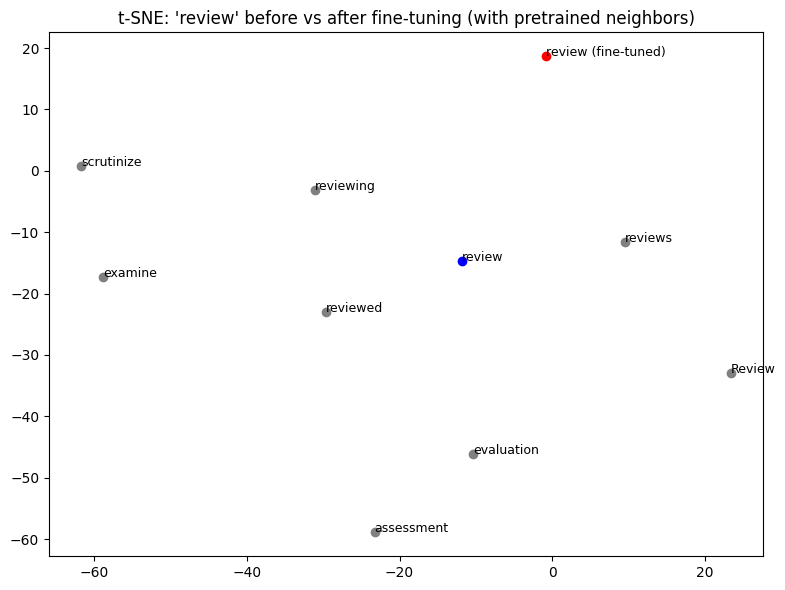

In [12]:
def main():
    pretrained_wv = load_pretrained()

    print("\n=== BEFORE fine-tuning: nearest neighbors ===")
    before_df = nearest_neighbors_table(pretrained_wv, TARGET_WORDS)
    print(before_df.to_string(index=False))

    sentences = load_imdb_sentences(max_docs=5000)

    print("\nFine-tuning on IMDB corpus ...")
    ft_model = fine_tune(pretrained_wv, sentences)
    finetuned_wv = ft_model.wv

    print("\n=== AFTER fine-tuning: nearest neighbors ===")
    after_df = nearest_neighbors_table(finetuned_wv, TARGET_WORDS)
    print(after_df.to_string(index=False))

    # Combined before/after comparison table
    before_df["stage"] = "before"
    after_df["stage"] = "after"
    combined = pd.concat([before_df, after_df], ignore_index=True)
    combined = combined.sort_values(["word", "stage", "rank"])
    combined.to_csv("neighbors_before_after.csv", index=False)
    print("\nSaved combined before/after table to neighbors_before_after.csv")

    print("\n=== Vector drift (cosine similarity original vs fine-tuned) ===")
    drift = drift_table(pretrained_wv, finetuned_wv, TARGET_WORDS)
    print(drift.to_string(index=False))
    drift.to_csv("drift_table.csv", index=False)

    most_shifted = drift.iloc[0]
    least_shifted = drift.iloc[-1]
    print(f"\nMost shifted word:  {most_shifted['word']} "
          f"(cosine sim = {most_shifted['cosine_sim(original, finetuned)']})")
    print(f"Least shifted word: {least_shifted['word']} "
          f"(cosine sim = {least_shifted['cosine_sim(original, finetuned)']})")

    # Visualize shift for the most-shifted word (usually most informative)
    plot_shift_tsne(pretrained_wv, finetuned_wv, most_shifted["word"])


if __name__ == "__main__":
    main()

### Run the full pipeline

In [ ]:
main()

Loading word2vec-google-news-300 ...

=== BEFORE fine-tuning: nearest neighbors ===
